## Import

In [ ]:
# 1) Environment / Imports (for debugging)
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np

import ansys.motorcad.core as pymotorcad

# Ensure repo root (folder containing 'tools/' or legacy 'tool/') is on sys.path
repo_root = pathlib.Path.cwd().resolve()
while not ((repo_root / "tools").exists() or (repo_root / "tool").exists()) and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print("repo_root:", repo_root)

# Force reload of local package during iterative edits
import importlib
import tools.motorCAD.pyMCAD as _pyMCAD
importlib.reload(_pyMCAD)

# Import utilities extracted from the notebook
from tools.motorCAD.pyMCAD import (
    get_magnetic_data,
    get_magnetic_data_from_file,
    get_magnetic_timeseries_from_file,
    interactive_magnetic_plot,
    interactive_magnetic_quiver,
    interactive_b_locus_field_plot,
    get_element_loss_fields,
    interactive_loss_fields_plot,
    mcad_default_export_dir,
    mcad_make_temp_txt_path,
    )

# Connect to Motor-CAD (uses existing instance by default)
mc = pymotorcad.MotorCAD(open_new_instance=False)

repo_root: D:\KangDH\Emlab_emach


In [2]:
# (Optional) Auto-reload local modules while you debug edits in tool/motorCAD/pyMCAD/*.py
try:
    %load_ext autoreload
    %autoreload 2
except Exception as e:
    print("autoreload not available:", e)

In [3]:
# 1.5) Enable zoomable Matplotlib backend (ipympl)
try:
    import ipympl  # noqa: F401
    get_ipython().run_line_magic("matplotlib", "widget")
    import matplotlib
    print("matplotlib backend:", matplotlib.get_backend())
except Exception as e:
    print("ipympl/widget backend not available; using default backend. Error:", e)

matplotlib backend: widget


# 1. Magnetic FEA export & debug
이 노트북은 `tool/motorCAD/pyMCAD` 아래로 분리된 모듈을 import해서 실행/디버깅합니다.

In [6]:
# 2) Export + Parse (time series)
from pathlib import Path
from datetime import datetime

# Output file base name
out_dir = mcad_default_export_dir(mc)
base_filename = Path(out_dir) / "MagTransient.txt"
print("Output dir:", out_dir)
print("Base output file:", base_filename)

# Export settings
DO_EXPORT = True
first_step = 1
final_step = 45

def _unique_filename_if_exists(path: Path) -> Path:
    """If 'path' exists, return a new path with a timestamp suffix."""
    if not path.exists():
        return path
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return path.with_name(f"{path.stem}_{stamp}{path.suffix}")

# Choose filename
if DO_EXPORT:
    filename = _unique_filename_if_exists(base_filename)
    mc.save_fea_data(str(filename), int(first_step), int(final_step), "RegCode,Bx,By,A,J", "", ",")
    print("Exported (unique):", filename)
else:
    filename = base_filename
    print("Skipped export; using existing file:", filename)

# Parse all blocks in file
ts = get_magnetic_timeseries_from_file(filename, key="time_index", verbose=True)
print("Parsed steps:", ts.steps[:10], "..." if len(ts.steps) > 10 else "")

Output dir: E:\KDH\AdaptiveTemplate
Base output file: E:\KDH\AdaptiveTemplate\MagTransient.txt
Exported (unique): E:\KDH\AdaptiveTemplate\MagTransient_20260107_225117.txt
Parsed block key=0: elements=11330, nodes=5874
Parsed block key=1: elements=11330, nodes=5882
Parsed block key=2: elements=11330, nodes=5890
Parsed block key=3: elements=11330, nodes=5899
Parsed block key=4: elements=11330, nodes=5907
Parsed block key=5: elements=11330, nodes=5915
Parsed block key=6: elements=11330, nodes=5923
Parsed block key=7: elements=11330, nodes=5932
Parsed block key=8: elements=11330, nodes=5940
Parsed block key=9: elements=11330, nodes=5948
Parsed block key=10: elements=11330, nodes=5956
Parsed block key=11: elements=11330, nodes=5965
Parsed block key=12: elements=11330, nodes=5973
Parsed block key=13: elements=11330, nodes=5976
Parsed block key=14: elements=11330, nodes=5976
Parsed block key=15: elements=11330, nodes=5976
Parsed block key=16: elements=11330, nodes=5976
Parsed block key=17: el

## Plots
아래 셀들은 `ts`(time series)를 대상으로 시각화합니다.

In [9]:
interactive_magnetic_plot(ts, quantity="b", s=2)

In [15]:
# Interactive quiver (step toggle)
# Tip: stride를 키우면 더 가볍게 볼 수 있습니다.
interactive_magnetic_quiver(ts, stride=1, scale=1, normalize=False)

# B-locus (all elements)

Plot each element’s $(B_x(t), B_y(t))$ locus as a small loop drawn at that element’s centroid.


In [ ]:
# Interactive B-locus (all elements)
# - Each element’s (Bx(t), By(t)) loop is drawn at its centroid
# - Region dropdown shows "reg_code: region_name" when available
interactive_b_locus_field_plot(ts)

matplotlib backend: widget


Output()

In [ ]:
# Mesh plot example (tri edges)
ts.plot_mesh(step=ts.steps[0] if ts.steps else 0)

# Loss export & plot
Motor-CAD의 `mc.save_fea_data`로 element-wise 손실 성분을 export한 뒤, `Pt/Phys/Pj/Peddy`를 스칼라 필드로 파싱해서 플로팅합니다. (현재 단위는 W/kg로 가정)

In [13]:
# Export + parse element-wise losses (single snapshot)
# Tip: loss는 보통 step별로 변하지 않는 집계값이라, 마지막 step만 export하는게 안전합니다.
from pathlib import Path

loss_step = int(final_step)

# Export next to the active .mot (same convention as other domains)
out_dir = mcad_default_export_dir(mc)
base_filename = Path(out_dir) / "LossElement.txt"
loss_export_path = _unique_filename_if_exists(base_filename)
print("Loss export path:", loss_export_path)

loss_fields = get_element_loss_fields(
    mc,
    filename=loss_export_path,
    step=loss_step,
    columns=("Pt", "Phys", "Pj", "Peddy"),
    unit="W/kg",
    clean_up=False,  # 파일을 남겨서 내용 확인 가능
 )
print("Parsed loss components:", list(loss_fields.keys()))

Loss export path: E:\KDH\AdaptiveTemplate\LossElement_20260107_225411.txt
Parsed loss components: ['Pt', 'Phys', 'Pj', 'Peddy']


In [14]:
# Interactive plot (component dropdown)
interactive_loss_fields_plot(loss_fields, s=2)

# 2. Mech FEA Export & Debug

In [8]:
mc.do_mechanical_calculation()
import importlib
from pathlib import Path
import tools.motorCAD.pyMCAD.stress as stress

importlib.reload(stress)  # pick up local edits without restarting kernel
region_names_to_postprocess = ["Rotor"]

# Export file name (domain-named)
out_dir = mcad_default_export_dir(mc)
base_filename = Path(out_dir) / "MechStress.txt"
stress_filename = _unique_filename_if_exists(base_filename)
print("Stress export file:", stress_filename)

stress_regions = stress.get_stress_data(mc, filename=stress_filename, clean_up=False)

# Single figure + dropdown to select region
stress.interactive_mesh_stress_fields_plot(
    stress_regions,
    region_names=region_names_to_postprocess,
    fields=("svm", "sp1", "sp2"),
    show_mesh=True,
    mesh_alpha=0.25,
    colorbar_location="top",
    title_suffix="(before correction)",
)

Stress export file: E:\KDH\AdaptiveTemplate\MechStress_20260107_225202.txt


Output()

(Dropdown(description='region', options=(('Rotor', 0),), value=0), Output())

# 3. Thermal FEA Export & Debug

In [102]:
# Thermal static export + plot (ThermalStatic*.txt)
from pathlib import Path

import importlib
import tools.motorCAD.pyMCAD.thermal as thermal
importlib.reload(thermal)

# Where to save
out_dir = mcad_default_export_dir(mc)
base_filename = Path(out_dir) / "ThermalStatic.txt"
filename = _unique_filename_if_exists(base_filename)
print("Thermal export file:", filename)

# Export + parse (single snapshot)
thermal_regions = thermal.get_thermal_data(
    mc,
    step=1,
    variables="RegCode,T,G,q",
    filename=filename,
    clean_up=False,
 )

# ---- Plot controls ----
# If the 'all' (merged) temperature looks odd, fix the color scale explicitly here.
t_min = 100  # e.g. 20.0
t_max = 150  # e.g. 140.0
field_clim = {
    "t": (t_min, t_max),
    # "g": (None, None),
    # "q": (None, None),
}

# Single figure + dropdown to select region (includes 'all')
thermal.interactive_mesh_thermal_fields_plot(
    thermal_regions,
    fields=("t", "g", "q"),
    show_mesh=True,
    mesh_alpha=0.25,
    # spacing between subplots
    subplot_wspace=0.5,
    # colorbar placement/spacing
    colorbar_location="top",
    colorbar_pad= 0.7,
    field_clim=field_clim,
    title_suffix="(ThermalStatic)",
)

Thermal export file: E:\KDH\AdaptiveTemplate\ThermalStatic_20260107_225002.txt


Output()

(Dropdown(description='region', options=(('all', -1), ('Rotor', 0), ('L1_1Magnet1', 1), ('L1_1Magnet2', 2), ('L2_1Magnet1', 3), ('L2_1Magnet2', 4)), value=-1),
 Output())

# 4. get Scalar Data & waveform

In [34]:
from pathlib import Path
from datetime import datetime

base_dir = Path(mc.get_variable("CurrentMotFileDir_MotorLAB"))
mot_path = Path(mc.get_file_name())
mot_stem = mot_path.stem if mot_path.suffix else mot_path.name
# Where MotorLAB typically writes its own outputs
lab_result_dir = base_dir / mot_stem

# Put our exports in a dedicated subfolder (safe, non-destructive)
export_dir = lab_result_dir / "_py_exports"
export_dir.mkdir(parents=True, exist_ok=True)
# Keep variable name for downstream convenience
working_folder = export_dir

mc.show_magnetic_context()

shaft_torque = mc.get_variable("ShaftTorque")
line_voltage = mc.get_variable("PeakLineLineVoltage")

In [36]:
# Back-EMF scalar metrics (functionized)
from tools.motorCAD.pyMCAD.melec_req_check import get_back_emf_metrics

metrics = get_back_emf_metrics(mc)
for k in ["ShaftTorque", "PeakLineLineVoltage", "PeakBackEMFLine", "RMSBackEMFLine", "PeakBackEMFPhase", "THDBackEMFLine"]:
    if k in metrics:
        unit = ""
        if "Torque" in k:
            unit = " Nm"
        elif "Voltage" in k or "EMF" in k:
            unit = " V"
        elif "THD" in k:
            unit = " %"
        print(f"{k}: {metrics[k]:.4g}{unit}")

ShaftTorque: 507.9 Nm
PeakLineLineVoltage: 1874 V
PeakBackEMFLine: 1230 V
RMSBackEMFLine: 844.4 V
PeakBackEMFPhase: 678.1 V
THDBackEMFLine: 5.719 V


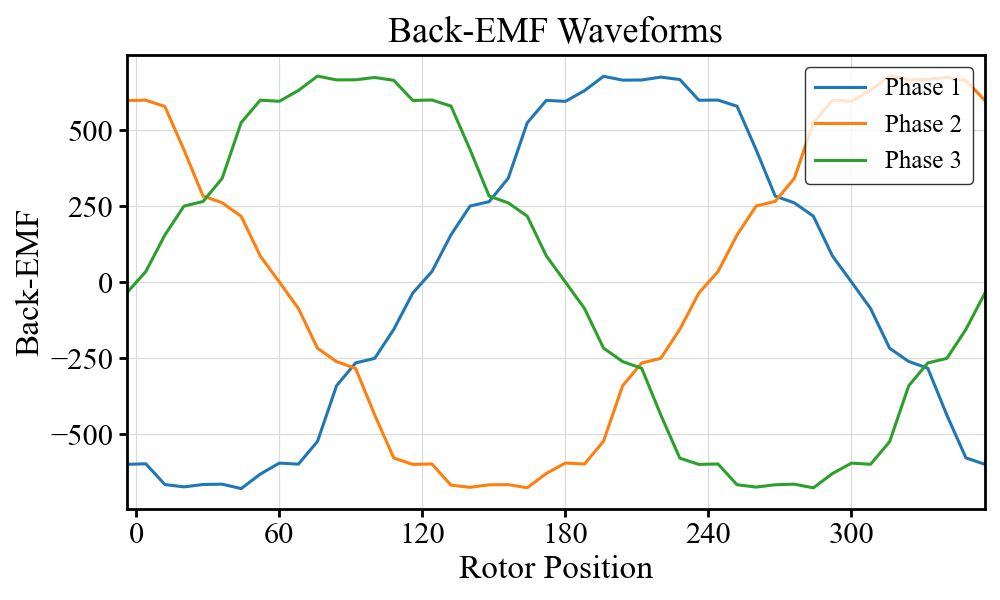

In [37]:
# Back-EMF Waveforms (functionized)
from tools.motorCAD.pyMCAD.melec_req_check import plot_back_emf_waveforms

fig, ax = plot_back_emf_waveforms(mc)

## load

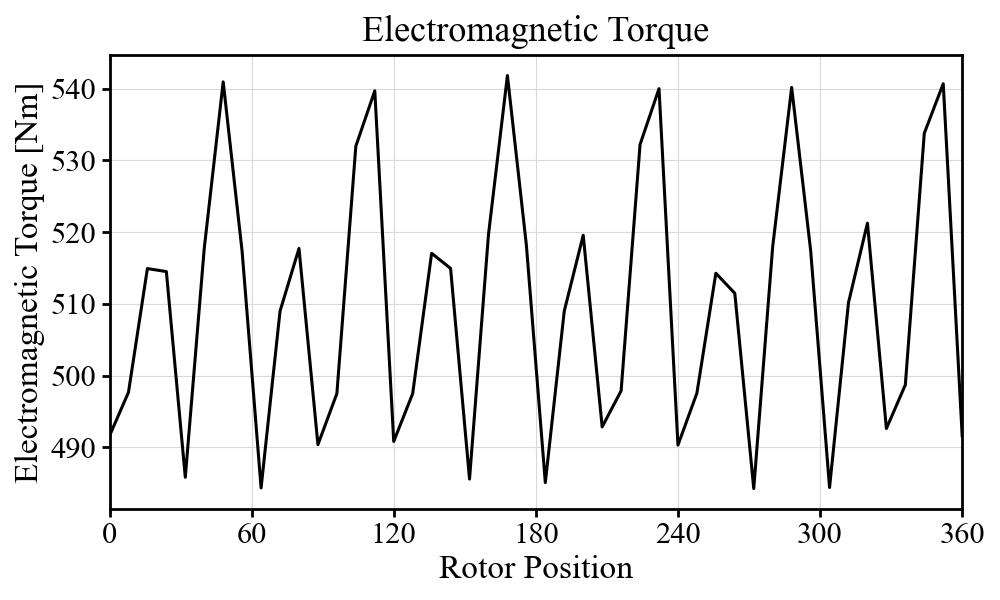

In [38]:
# TorqueVW waveform (functionized)
from tools.motorCAD.pyMCAD.melec_req_check import plot_torque_vw_waveform

fig, ax = plot_torque_vw_waveform(mc)

## Graph Catalog (INI) + Live API Fetch
- `testGraph.ini` is used only to list available graph names and decide `DataType`.
- Actual waveform data is always fetched from Motor-CAD API (`get_magnetic_graph` / `get_fea_graph`).

INI graph count: 104
Terminal voltage candidates: ['TerminalVoltage1_M', 'TerminalVoltage2_M', 'TerminalVoltage3_M', 'TerminalVoltageA_1_M', 'TerminalVoltageB_1_M', 'TerminalVoltageC_1_M']
Flux linkage candidates: ['FluxLinkageOCPh1_M', 'FluxLinkageOCPh2_M', 'FluxLinkageOCPh3_M', 'FluxLinkageOCD_M', 'FluxLinkageOCQ_M', 'FluxLinkageOCPh1_1_M', 'FluxLinkageOCPh2_1_M', 'FluxLinkageOCPh3_1_M', 'FluxLinkageLoadPh1_M', 'FluxLinkageLoadPh2_M']


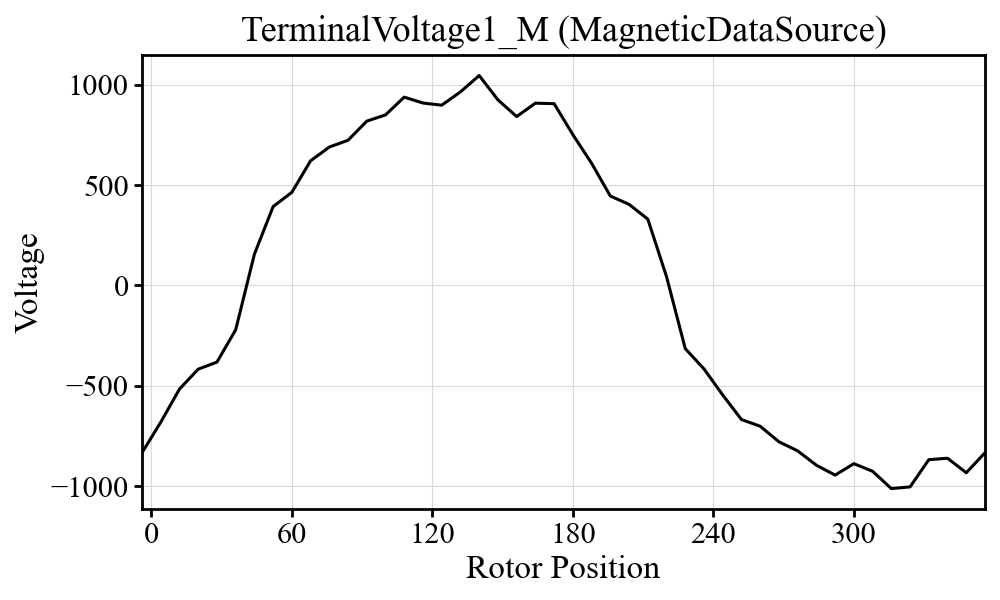

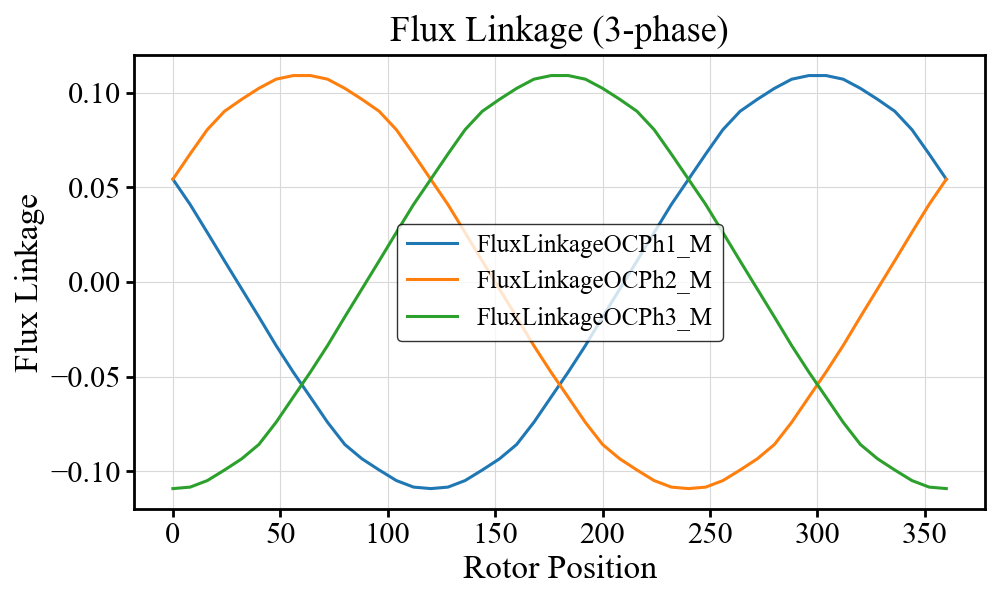

In [39]:
from pathlib import Path
import importlib

# Ensure the package re-exports are up-to-date in this kernel session
import tools.motorCAD.pyMCAD as pyMCAD
importlib.reload(pyMCAD)

try:
    from tools.motorCAD.pyMCAD import (
        list_graph_names_from_ini,
        get_graph_type_map_from_ini,
        plot_graph_waveform,
        plot_multi_graph_waveforms,
    )
except ImportError as e:
    print("pyMCAD re-export import failed; falling back to submodule import. Error:", e)
    from tools.motorCAD.pyMCAD.melec_req_check import (
        list_graph_names_from_ini,
        get_graph_type_map_from_ini,
        plot_graph_waveform,
        plot_multi_graph_waveforms,
    )

# Baseline catalog INI (static). Adjust to your environment.
ini_path = Path(r"e:\KDH\AdaptiveTemplate\TestCAD1\testGraph.ini")

type_map = get_graph_type_map_from_ini(ini_path)
print(f"INI graph count: {len(type_map)}")

# Example 1) Terminal voltage (pick first match from catalog, fetch data via API)
tv_names = list_graph_names_from_ini(ini_path, contains=["TerminalVoltage"])
print("Terminal voltage candidates:", tv_names[:10])
if tv_names:
    name = tv_names[0]
    dt = type_map.get(name)
    fig, ax = plot_graph_waveform(
        mc,
        name,
        data_type=dt,
        title=f"{name} ({dt})",
        xlabel="Rotor Position",
        ylabel="Voltage",
    )

# Example 2) Flux linkage (try 3-phase, fetch each trace via API)
fl_names = list_graph_names_from_ini(ini_path, contains=["FluxLinkage"])
print("Flux linkage candidates:", fl_names[:10])
if len(fl_names) >= 3:
    names3 = fl_names[:3]
    fig, ax = plot_multi_graph_waveforms(
        mc,
        names3,
        data_type=type_map.get(names3[0]),
        title="Flux Linkage (3-phase)",
        xlabel="Rotor Position",
        ylabel="Flux Linkage",
    )



# Motor Analysis Process 1-2-3-4 